In [1]:
import matplotlib.pyplot as plt
from skimage import draw
import numpy as np
from os import mkdir
from os.path import isdir
import os.path

from PhantomGenerators import DifferentGrayLevels, EdgeImage, ShrinkShape, CartesianToPolar, CreateBlob

# Some constants that are used throughout the notebook
MAX_GRAY_VAL = 255
MIN_GRAY_VAL = 0
IMG_SHAPE = (512, 512)
RNG = np.random.default_rng(seed=68)

if not os.path.exists("Geo_phantom/phantom_arrays/"):
    mkdir("Geo_phantom/phantom_arrays")

### First shape

We will start with generating a basic kite shape.

Unique gray levels are: [  0 255]


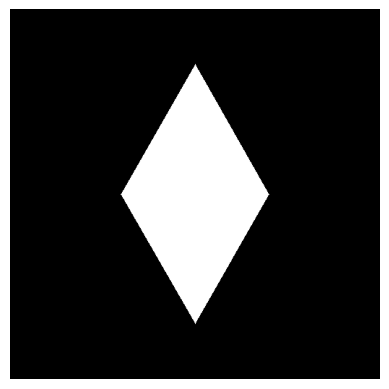

In [2]:
# you can change the seed to generate a slightly different phantom
img = np.zeros(IMG_SHAPE)

deltaHeight, deltaWidth = 0.3, 0.6
diamond_x, diamond_y = [int(deltaHeight*256), 256, int((2-deltaHeight)*256), 256], [256, int(deltaWidth*256), 256, int((2-deltaWidth)*256)]
rr, cc = draw.polygon(diamond_x, diamond_y, shape=img.shape)
img[rr, cc] = 1

img = img * MAX_GRAY_VAL
img[img > 255] = MAX_GRAY_VAL
img[img < 0] = MIN_GRAY_VAL
img = img.astype(np.int16)

print("Unique gray levels are:", np.unique(img))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.savefig("Geo_phantom/binary_triangle.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/binary_triangle", img)

#### Adding a second gray level

The addition of another gray level is done through the function `DifferentGrayLevels`. This function requires you to add the "img" as an argument, and the number of different gray levels. Note that the background (black) is also seen as a gray level.

Unique gray levels: [  0 127 255]


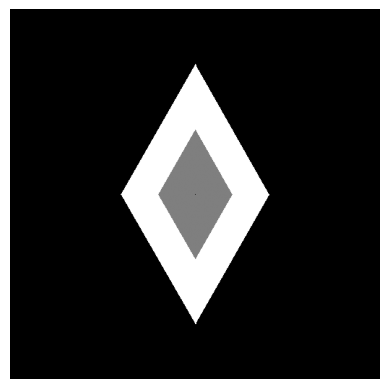

In [3]:

img2 = DifferentGrayLevels(img, levels=3)

print("Unique gray levels:",np.unique(img2))
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.savefig("Geo_phantom/two_gray_triangle.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/two_gray_triangle", img2)

You can even add more different gray values

Unique gray levels: [  0  63 127 191 255]


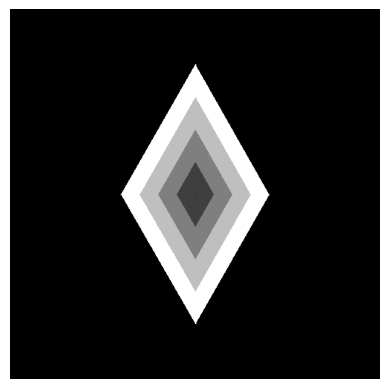

In [4]:

img2 = DifferentGrayLevels(img, levels=5)

print("Unique gray levels:",np.unique(img2))
plt.imshow(img2, cmap='gray')
plt.axis('off')
plt.savefig("Geo_phantom/multiple_gray_triangle.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/multiple_gray_triangle", img2)

### More geometrical shapes

We can create a number of random geomtric shapes by using the `draw.random_shapes` function. This allows you to generate a number of geomtric shapes within a boundry. The White outer ring is created by making a white disk, and filling it again with a smaller black disk

Unique gray levels are: [  0. 255.]


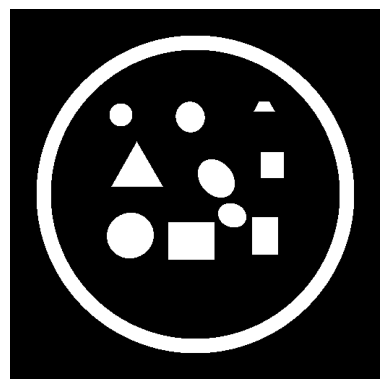

In [14]:
"""Random geometrical shapes all of the same gray level. The random geometrical shapes are surrounded by a circle to see how the algorithm can handle that all the 
random object are enclosed and if the algorithm can detect that properly"""

img = np.zeros(IMG_SHAPE)

# White outer 
w_disk_c, w_disk_r = (256, 256), 220
rr, cc = draw.disk(w_disk_c, w_disk_r, shape=img.shape)
img[rr, cc] = MAX_GRAY_VAL

b_disk_c, b_disk_r = (256, 256), 200
rr, cc = draw.disk(b_disk_c, b_disk_r, shape=img.shape)
img[rr, cc] = MIN_GRAY_VAL

img = img * MAX_GRAY_VAL
image, shape = draw.random_shapes((256, 256), 15, 10, min_size=30, max_size=80, intensity_range=[(20, 21),], rng=69)
img[128:512-128, 128:512-128] = image[:,:,0]*255

img[img > 255/2] = MAX_GRAY_VAL
img[img < 255/2] = MIN_GRAY_VAL

print(f"Unique gray levels are: {np.unique(img)}")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.savefig("Geo_phantom/Random_geo_shapes.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/Random_geo_shapes", img)

### Overlapping ellipses

The overlapping ellipses are created by generating ellipses at random positions, at different angles and shapes. Overlapping ellipses get brighter

Unique gray levels are: [  0.  76. 153. 229.]


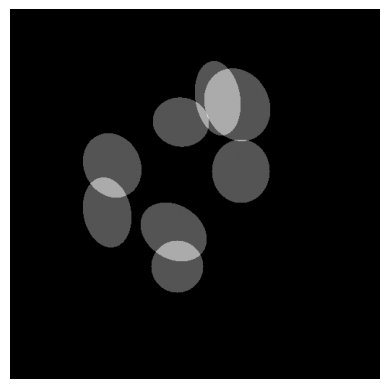

In [15]:
"""Ellipsoides that have random shapes, and rotations that can overlap. Each ellipsoid has a gray level of 77. If two ellipses overlap the intensity gets increased to 
153, and so forth. This figure contains geometrical shapes with overlap but without a surrounding structure"""

img = np.zeros((IMG_SHAPE))

RNG = np.random.default_rng(23)
num_shapes = RNG.integers(8, 15, size=1)[0]
for _ in range(num_shapes):
    r, c = RNG.integers(100, 400, size=2)
    r_radius, c_radius = RNG.integers(30, 60, size=2)
    rot = RNG.integers(0, 180, size=1)[0]
    rr, cc = draw.ellipse(r, c, r_radius, c_radius, rotation=rot, shape=IMG_SHAPE)
    img[rr, cc] += 0.3


img *= MAX_GRAY_VAL
img[img > 255] = MAX_GRAY_VAL
img[img < 0] = MIN_GRAY_VAL
img = np.round(img)

print(f"Unique gray levels are: {np.unique(img)}")
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.savefig("Geo_phantom/Overlapping_ellipses.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/Overlapping_ellipses", img)


### Famous phantom

The name of this phantom is unknown to us but it was recreated by drawing shapes over each other with different intensities, shapes and rotations. It was estimated with the naked eye

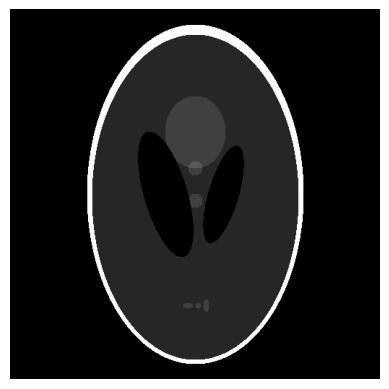

In [16]:
img = np.zeros(IMG_SHAPE)

outerEllipse_rr, outerEllipse_cc = draw.ellipse(256, 256, 235, 150, rotation=0, shape=img.shape)
img[outerEllipse_rr, outerEllipse_cc] = 1

innerEllipse_rr, innerEllipse_cc = draw.ellipse(260, 256, 225, 143, rotation=0, shape=img.shape)
img[innerEllipse_rr, innerEllipse_cc] = 0.15 

tinyCenterCircle_rr, tinyCenterCircle_cc = draw.ellipse(265, 256, 10, 10, rotation=0, shape=img.shape)
img[tinyCenterCircle_rr, tinyCenterCircle_cc] += 0.1 

upperTinyCenterCircle_rr, upperTinyCenterCircle_cc = draw.ellipse(220, 256, 10, 10, rotation=0, shape=img.shape)
img[upperTinyCenterCircle_rr, upperTinyCenterCircle_cc] += 0.1

bigTinyCenterCircle_rr, bigTinyCenterCircle_cc = draw.ellipse(170, 256, 50, 42, rotation=0, shape=img.shape)
img[bigTinyCenterCircle_rr, bigTinyCenterCircle_cc] += 0.1

darkLeftEllipse_rr, darkLeftEllipse_cc = draw.ellipse(256, 215, 90, 30, rotation=2/7, shape=img.shape)
img[darkLeftEllipse_rr, darkLeftEllipse_cc] = 0

darkRightEllipse_rr, darkRightEllipse_cc = draw.ellipse(256, 295, 70, 21, rotation=-2/7, shape=img.shape)
img[darkRightEllipse_rr, darkRightEllipse_cc] = 0

tinyLowerCircle_rr, tinyLowerCircle_cc = draw.ellipse(410, 260, 4, 4, rotation=0, shape=img.shape)
img[tinyLowerCircle_rr, tinyLowerCircle_cc] += 0.1

lowerRightEllipse_rr, lowerRightEllipse_cc = draw.ellipse(410, 271, 9, 4, rotation=0, shape=img.shape)
img[lowerRightEllipse_rr, lowerRightEllipse_cc] += 0.1
lowerRightEllipse_rr, lowerRightEllipse_cc = draw.ellipse(410, 246, 4, 7, rotation=0, shape=img.shape)
img[lowerRightEllipse_rr, lowerRightEllipse_cc] += 0.1


img *= MAX_GRAY_VAL
img[img > MAX_GRAY_VAL] = MAX_GRAY_VAL
img[img < MIN_GRAY_VAL] = MIN_GRAY_VAL  

plt.imshow(img, cmap='gray')
plt.axis("off")
plt.savefig("Geo_phantom/multiple_shapes_and_graylevels.png", bbox_inches='tight')
plt.show()

np.savez("Geo_phantom/phantom_arrays/multiple_shapes_and_graylevels", img)

